In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#Load dataset
file_path = "Telco_customer_churn.xlsx"
df = pd.read_excel(file_path)

print(df.head())

   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

In [161]:
#Data inspection
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nChurn distribution:")
print(df["Churn Label"].value_counts())

Shape of dataset: (7043, 33)

Column names:
Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

Data types:
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            obje

In [162]:
#Summary Stats Table
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
        Count      Zip Code     Latitude    Longitude  Tenure Months  \
count  7043.0   7043.000000  7043.000000  7043.000000    7043.000000   
mean      1.0  93521.964646    36.282441  -119.798880      32.371149   
std       0.0   1865.794555     2.455723     2.157889      24.559481   
min       1.0  90001.000000    32.555828  -124.301372       0.000000   
25%       1.0  92102.000000    34.030915  -121.815412       9.000000   
50%       1.0  93552.000000    36.391777  -119.730885      29.000000   
75%       1.0  95351.000000    38.224869  -118.043237      55.000000   
max       1.0  96161.000000    41.962127  -114.192901      72.000000   

       Monthly Charges  Churn Value  Churn Score         CLTV  
count      7043.000000  7043.000000  7043.000000  7043.000000  
mean         64.761692     0.265370    58.699418  4400.295755  
std          30.090047     0.441561    21.525131  1183.057152  
min          18.250000     0.000000     5.000000  2003.000000  
25%       

In [163]:
#Data Cleaning
#Convert Total Charges to numeric
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

#Check data type and missing values
print(df["Total Charges"].dtype)
print(df["Total Charges"].isnull().sum())

float64
11


In [164]:
#Drop any rows with missing Total Charges
df = df.dropna(subset=["Total Charges"])

In [165]:
#Check missing values
print(df["Total Charges"].isnull().sum())

0


In [166]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

Shape of dataset: (7032, 33)

Column names:
Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')


In [167]:
#Exploratory Data Analysis(EDA)
#Set Seaborn style
sns.set(style="whitegrid")

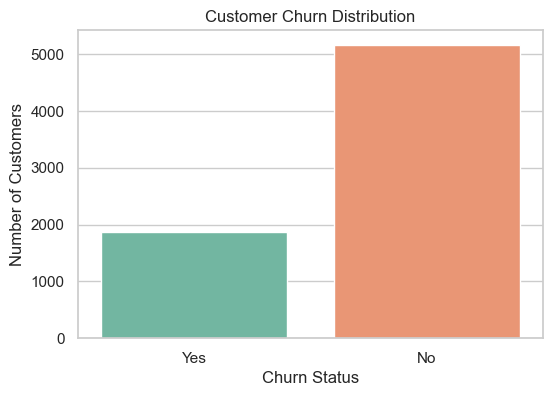

In [168]:
#1. Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn Label", hue="Churn Label", palette="Set2", legend=False)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

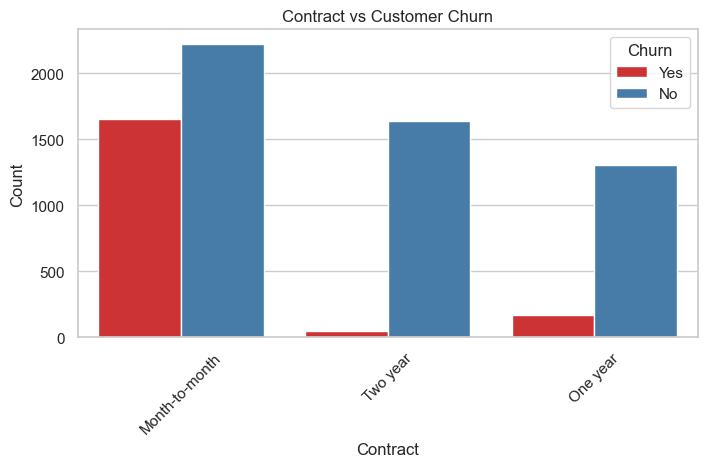

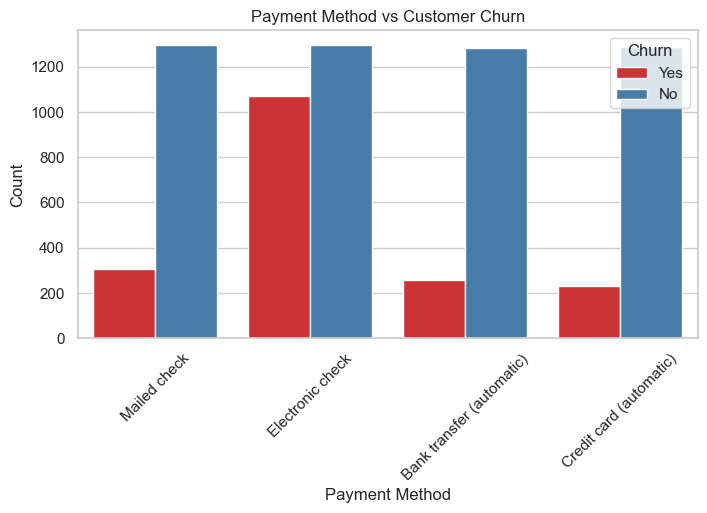

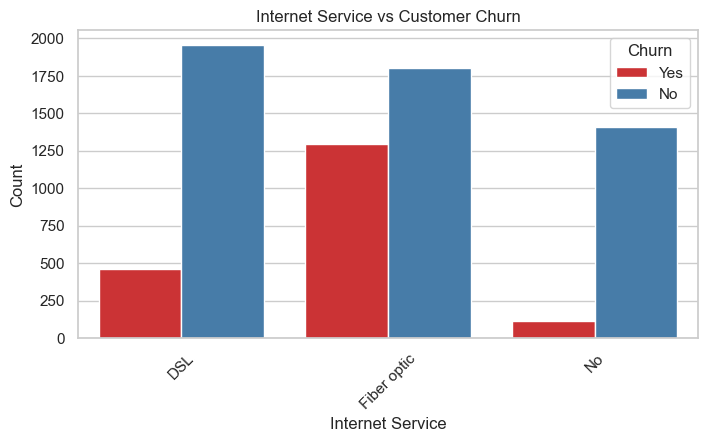

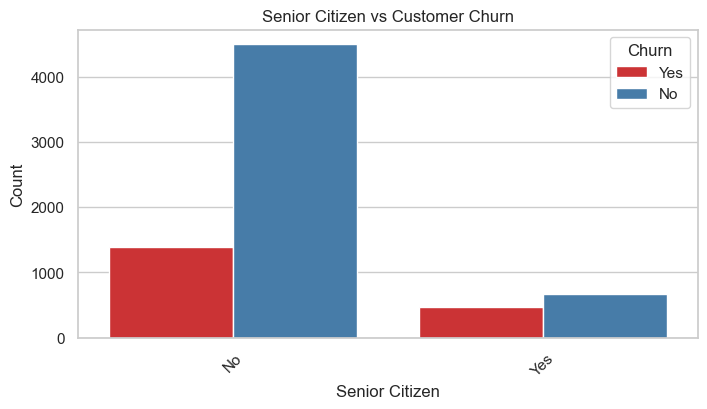

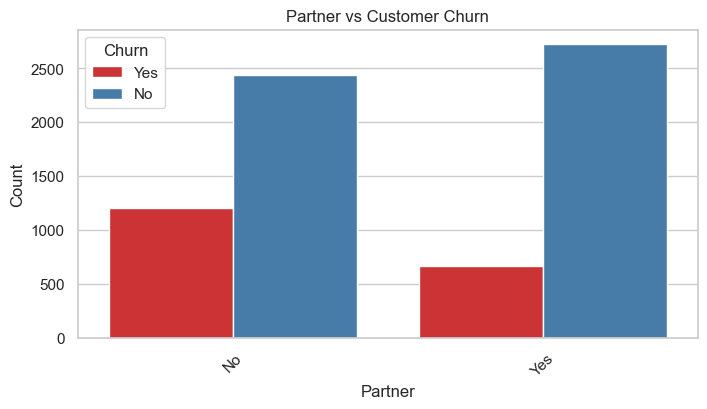

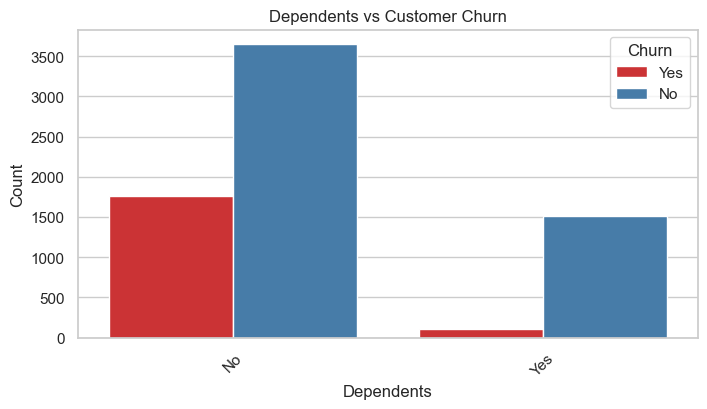

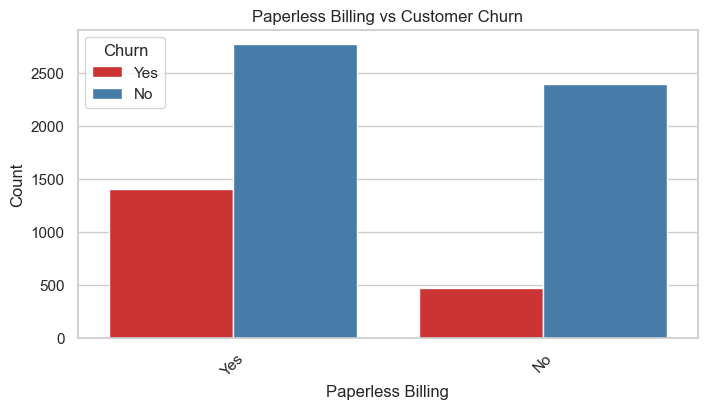

In [169]:
#2. Categorical Features vs Churn
categorical_features = [
    "Contract", "Payment Method", "Internet Service",
    "Senior Citizen", "Partner", "Dependents", "Paperless Billing"
]

for col in categorical_features:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue="Churn Label", palette="Set1")
    plt.title(f"{col} vs Customer Churn")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(title="Churn")
    plt.show()


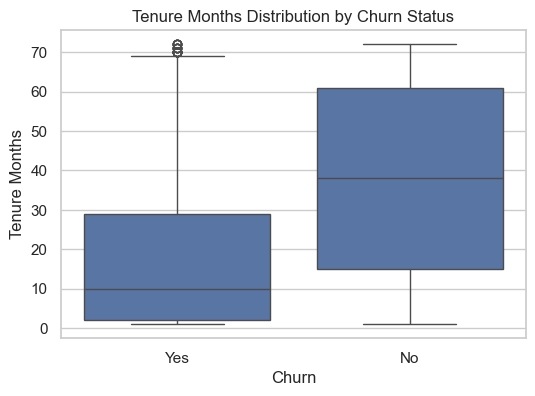

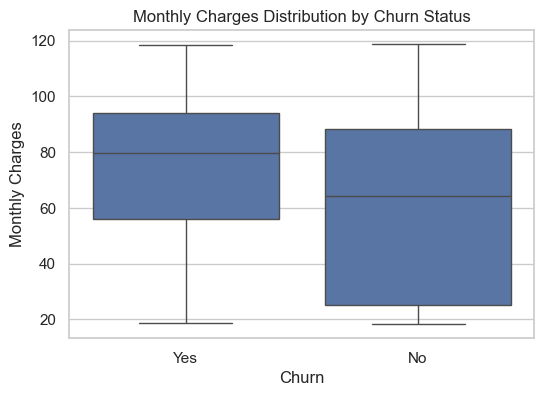

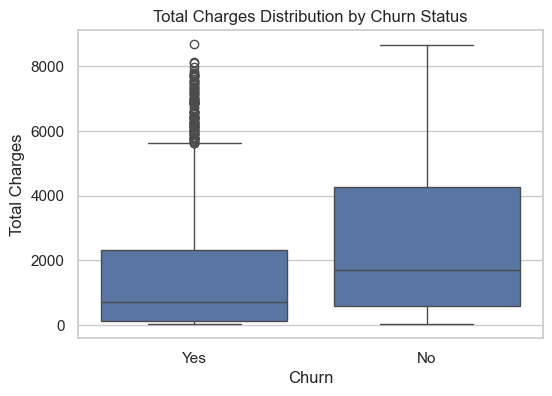

In [170]:
#3. Numeric Features vs Churn
numeric_features = ["Tenure Months", "Monthly Charges", "Total Charges"]

for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Churn Label", y=col)
    plt.title(f"{col} Distribution by Churn Status")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()


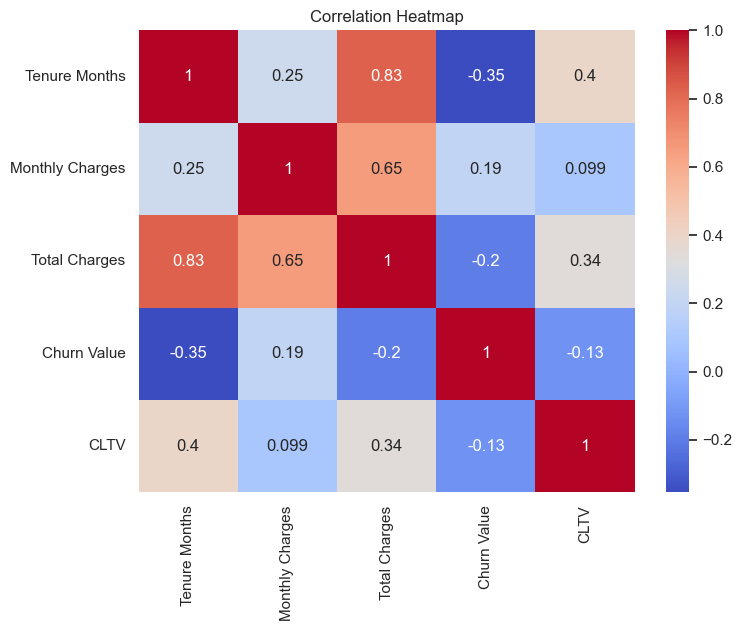

In [171]:
#4. Correlation Heatmap
numeric_cols = ["Tenure Months", "Monthly Charges", "Total Charges", "Churn Value", "CLTV"]

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

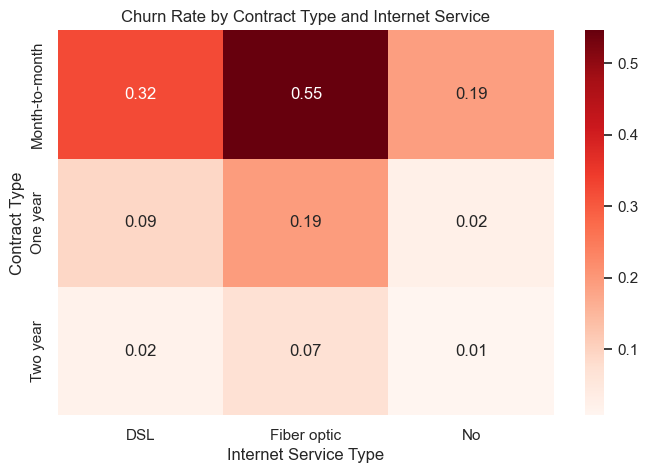

In [172]:
#5. Churn Rate Heatmap
#Create churn rate table
churn_rate = pd.crosstab(
    df["Contract"],
    df["Internet Service"],
    values=df["Churn Value"],
    aggfunc="mean"
)

#Plot heatmap
plt.figure(figsize=(8,5))
sns.heatmap(churn_rate, annot=True, fmt=".2f", cmap="Reds")

plt.title("Churn Rate by Contract Type and Internet Service")
plt.xlabel("Internet Service Type")
plt.ylabel("Contract Type")

plt.show()

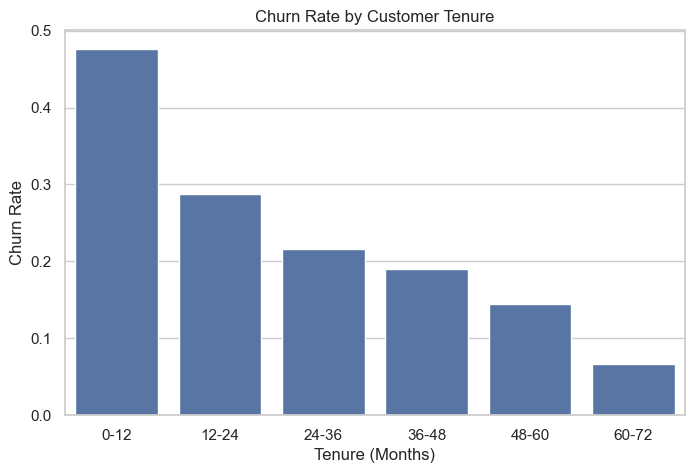

In [173]:
#6. Churn Rate by Customer Tenure
#Create tenure groups (bins)
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=["0-12", "12-24", "24-36", "36-48", "48-60", "60-72"]
)

#Calculate churn rate for each tenure group
tenure_churn = df.groupby("Tenure Group", observed=False)["Churn Value"].mean()

#Plot
plt.figure(figsize=(8,5))
sns.barplot(x=tenure_churn.index, y=tenure_churn.values)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate")

plt.show()

In [174]:
#Prepping data for ML

#Remove unnecessary columns
columns_to_drop = [
    "CustomerID",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Count",
    "Churn Score",
    "CLTV",
    "Churn Reason",
    "Tenure Group"
]

df = df.drop(columns=columns_to_drop)

In [175]:
print(df.head())

   Gender Senior Citizen Partner Dependents  Tenure Months Phone Service  \
0    Male             No      No         No              2           Yes   
1  Female             No      No        Yes              2           Yes   
2  Female             No      No        Yes              8           Yes   
3  Female             No     Yes        Yes             28           Yes   
4    Male             No      No        Yes             49           Yes   

  Multiple Lines Internet Service Online Security Online Backup  ...  \
0             No              DSL             Yes           Yes  ...   
1             No      Fiber optic              No            No  ...   
2            Yes      Fiber optic              No            No  ...   
3            Yes      Fiber optic              No            No  ...   
4            Yes      Fiber optic              No           Yes  ...   

  Tech Support Streaming TV Streaming Movies        Contract  \
0           No           No               No  

In [176]:
#Summary Stats Table
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       Tenure Months  Monthly Charges  Total Charges  Churn Value
count    7032.000000      7032.000000    7032.000000  7032.000000
mean       32.421786        64.798208    2283.300441     0.265785
std        24.545260        30.085974    2266.771362     0.441782
min         1.000000        18.250000      18.800000     0.000000
25%         9.000000        35.587500     401.450000     0.000000
50%        29.000000        70.350000    1397.475000     0.000000
75%        55.000000        89.862500    3794.737500     1.000000
max        72.000000       118.750000    8684.800000     1.000000


In [177]:
print("\nColumn names:")
print(df.columns)


Column names:
Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value'],
      dtype='object')


In [178]:
# Export cleaned dataset for Tableau
df.to_csv("telco_churn_cleaned.csv", index=False)

In [179]:
#Define Target(y) and Features(x)

# Target variable
y = df["Churn Value"]

# Features
X = df.drop(columns=["Churn Label", "Churn Value"])

In [180]:
#Encode Categorical Variables
X = pd.get_dummies(X, drop_first=True)

print("Number of features:", X.shape[1])

Number of features: 30


In [181]:
#Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [182]:
#Check dataset size
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (5625, 30)
Test set shape: (1407, 30)


In [183]:
#Import scaler
from sklearn.preprocessing import StandardScaler

#Scale training and test data
#Scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [184]:
#Train Model

#Logistic Regression Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [185]:
#Evaluate the model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7569296375266524

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1012
           1       0.54      0.82      0.65       395

    accuracy                           0.76      1407
   macro avg       0.73      0.77      0.73      1407
weighted avg       0.81      0.76      0.77      1407


Confusion Matrix:
[[743 269]
 [ 73 322]]


In [186]:
#Feature Importance (Logistic Regression)

#Get feature names
feature_names = X.columns

#Get coefficients
coefficients = model.coef_[0]

#Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

#Sort by importance (absolute value)
feature_importance["Abs Coefficient"] = feature_importance["Coefficient"].abs()
feature_importance = feature_importance.sort_values(by="Abs Coefficient", ascending=False)

#Show top 10
top_features = feature_importance.head(10)

print(top_features)

                            Feature  Coefficient  Abs Coefficient
0                     Tenure Months    -1.419780         1.419780
2                     Total Charges     0.713180         0.713180
6                    Dependents_Yes    -0.635456         0.635456
25                Contract_Two year    -0.631038         0.631038
24                Contract_One year    -0.283819         0.283819
10     Internet Service_Fiber optic     0.250052         0.250052
26            Paperless Billing_Yes     0.189004         0.189004
13              Online Security_Yes    -0.186401         0.186401
5                       Partner_Yes     0.147689         0.147689
28  Payment Method_Electronic check     0.138855         0.138855


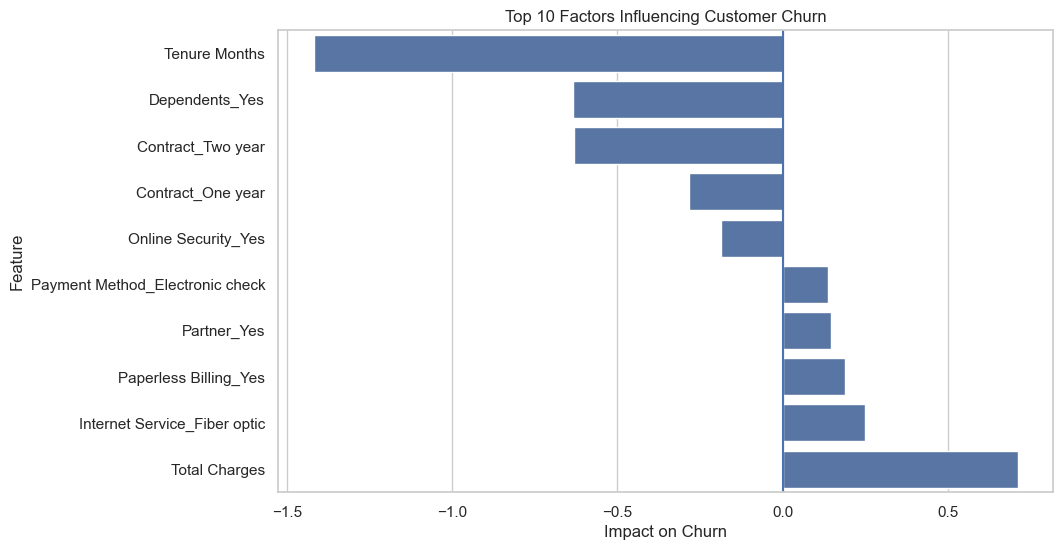

In [187]:
#Visualize top churn drivers
#Plot top 10 features
#Sort so positive and negative are separated visually
top_features = top_features.sort_values(by="Coefficient")

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.axvline(0)  #Adds vertical line at 0

plt.title("Top 10 Factors Influencing Customer Churn")
plt.xlabel("Impact on Churn")
plt.ylabel("Feature")

plt.show()

In [188]:
#Train Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [189]:
#Evaluate the model

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.7945984363894811

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1012
           1       0.68      0.50      0.58       395

    accuracy                           0.79      1407
   macro avg       0.75      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407


Random Forest Confusion Matrix:
[[921  91]
 [198 197]]


In [190]:
#Feature Importance (Random Forest)

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)


# Top 10 features
rf_top_features = rf_importance.head(10)

print(rf_top_features)

                            Feature  Importance
2                     Total Charges    0.190995
0                     Tenure Months    0.169277
1                   Monthly Charges    0.165979
28  Payment Method_Electronic check    0.040334
10     Internet Service_Fiber optic    0.037762
6                    Dependents_Yes    0.037748
25                Contract_Two year    0.029398
3                       Gender_Male    0.027417
5                       Partner_Yes    0.024858
13              Online Security_Yes    0.024752


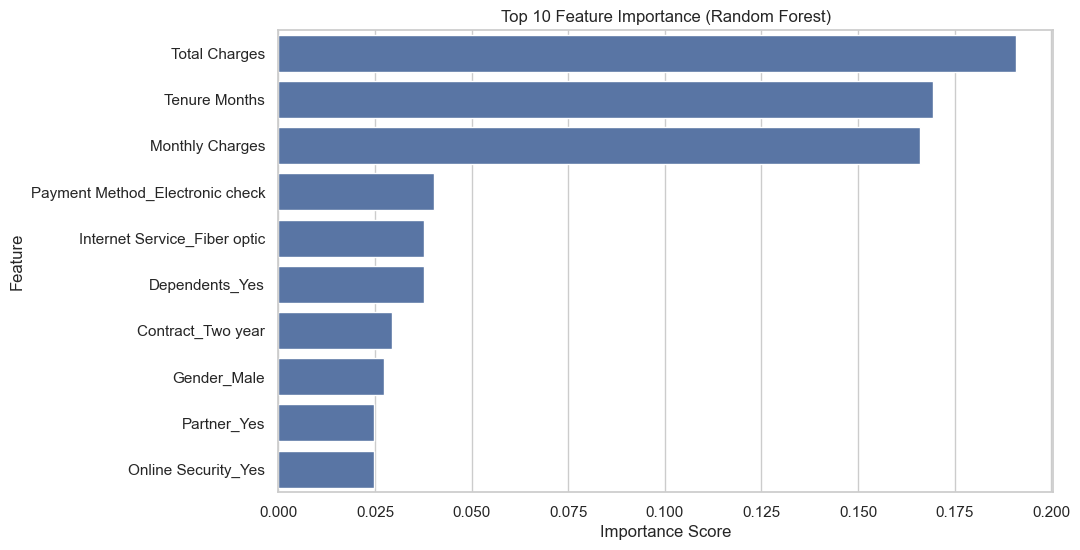

In [191]:
#Visualize Top Features

plt.figure(figsize=(10,6))
sns.barplot(
    data=rf_top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()